In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [4]:
url =  "https://www.croma.com/l/high-definition-laptop.html"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
products = soup.find_all("h3")
print(products)



[<h3 class="title show-on-mobile"><span class="icon icon-close" data-testid="filterdatael"></span> Filters </h3>, <h3 class="title">Sort By</h3>, <h3 class="product-title plp-prod-title 999" data-v-15bb1a44=""><a data-v-15bb1a44="" href="https://www.croma.com/lenovo-ideapad-pro-5-14imh9-intel-core-ultra-9-laptop-32gb-1tb-ssd-windows-11-home-14-inch-2-8k-oled-display-ms-office-2024-arctic-grey-1-46-kg-/p/315084" rel="noopener noreferrer" target="_blank">Lenovo IdeaPad Pro 5 14IMH9 Intel Core Ultra 9 Laptop (32GB, 1TB SSD, Windows 11 Home, 14 inch 2.8K OLED Display, MS Office 2024, Arctic Grey, 1.46 KG)</a></h3>, <h3 class="product-title plp-prod-title 999" data-v-15bb1a44=""><a data-v-15bb1a44="" href="https://www.croma.com/hp-14-gr1028tu-intel-core-ultra-7-thin-light-laptop-16gb-512gb-ssd-windows-11-home-14-inch-full-hd-display-natural-silver-1-4-kg-/p/316530" rel="noopener noreferrer" target="_blank">HP 14-gr1028TU Intel Core Ultra 7 Thin &amp; Light Laptop (16GB, 512GB SSD, Windows 1

In [8]:
names = []

for product in products:
    names.append(product.text.strip())

print(names[:10])

['', 'Home', 'High Definition Laptops', 'Batteries, Chargers & Adapters (1)', 'Computer And Laptop Accessories (2)', 'Computers & Tablets (199)', 'Gaming (1)', 'Gaming Accessories (1)', 'Gaming Laptops (77)', 'Laptop Webcams & Mics (1)']


In [20]:
prices = soup.find_all(string=lambda x: "₹" in x)

price_list = []

for p in prices:
    price_list.append(p.strip())

print(price_list[:10])

['₹ 1,12,990', '₹1,59,490', '(Save ₹46,500 )', '₹ 78,999', '₹85,990', '(Save ₹6,991 )', '₹ 92,990', '₹1,04,047', '(Save ₹11,057 )', '₹ 60,990']


In [15]:
data = pd.DataFrame({
"Product Name": names[:len(price_list)],
"Price": price_list
})


In [16]:
data

,Product Name,Price
0,,"₹ 1,12,990"
1,Home,"₹1,59,490"
2,High Definition Laptops,"(Save ₹46,500 )"
3,"Batteries, Chargers & Adapters (1)","₹ 78,999"
4,Computer And Laptop Accessories (2),"₹85,990"
...,...,...
67,Msi (6),"₹1,13,944"
68,Samsung (5),"(Save ₹21,945 )"
69,Zebronics (1),"₹ 61,990"
70,500 & Below (1),"₹74,489"


In [11]:
data.to_csv("croma_laptop_data.csv", index=False)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product Name  72 non-null     object
 1   Price         72 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB


In [30]:
data["Price"] = data["Price"].str.replace("₹","")
data["Price"] = data["Price"].str.replace(",","")


In [32]:
data["Price"] = data["Price"].str.replace("[^0-9]", "", regex=True)
data["Price"] = data["Price"].astype(int)

print(data["Price"])

0     112990
1     159490
2      46500
3      78999
4      85990
       ...  
67    113944
68     21945
69     61990
70     74489
71     12499
Name: Price, Length: 72, dtype: int64


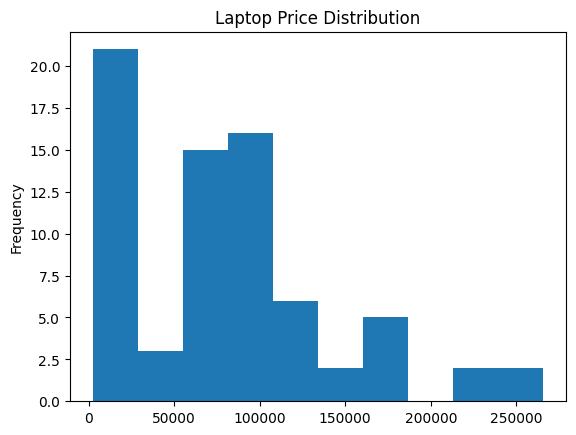

In [33]:
import matplotlib.pyplot as plt

data["Price"].astype(int).plot(kind="hist")

plt.title("Laptop Price Distribution")
plt.show()